#### Note: All data in this repo is synthetically made including sleep stage annotations, demographics or diseases. The data is for demo purposes only.


In [1]:
import pyedflib

In [2]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device Count:", torch.cuda.device_count())

CUDA Available: True
Device Count: 1


In [3]:
%load_ext autoreload 
%autoreload 2

#### Preprocessing Details


Before running this notebook, please preprocess your PSG files using the scripts provided in `sleepfm/preprocessing`. Note that PSG recordings may contain different sets of channels across datasets. The predefined channel–modality mappings used in this project are specified in `sleepfm/configs/channel_groups.json`.

Although we have attempted to make this mapping as comprehensive as possible, we strongly recommend reviewing the channels present in your specific PSG data. In consultation with domain experts, you should group any additional or dataset-specific channels into the appropriate modality categories and update `channel_groups.json` accordingly. This step is critical to ensure that all channels are correctly aligned with their intended modalities during preprocessing and downstream modeling.

In [4]:
import torch #토치
from torch import nn #신경망레이어
import numpy as np #
from sklearn.metrics import f1_score, confusion_matrix
import os
import tqdm
import random
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import pandas as pd
sys.path.append("..")
sys.path.append("../sleepfm")
from preprocessing.preprocessing import EDFToHDF5Converter
from models.dataset import SetTransformerDataset, collate_fn
from models.models import SetTransformer, SleepEventLSTMClassifier, DiagnosisFinetuneFullLSTMCOXPHWithDemo
import h5py
from utils import load_config, load_data, save_data, count_parameters
from torch.utils.data import Dataset, DataLoader

#### Part 0: Preprocessing EDF files

Note: This is just a demo notebook that preprocesses a single, specific file. run `sleepfm/preprocessing/preprocessing.sh` with appropriate folders to generate multiple preprocessed files.

In [5]:
base_save_path = "demo_data"
os.makedirs(base_save_path, exist_ok=True)#지정한 경로("demo_data")에 폴더를 생성합니다.

In [6]:
import matplotlib.pyplot as plt
from pyedflib import highlevel

edf_path = "demo_data/demo_psg.edf"
a = highlevel.read_edf(edf_path)
print(a)

(array([[2.67032883e-06, 2.00427253e-06, 2.89120317e-06, ...,
        2.51941711e-06, 2.51941711e-06, 2.51941711e-06],
       [2.98764019e-06, 2.82787823e-06, 1.82635233e-06, ...,
        2.47852293e-06, 2.47852293e-06, 2.47852293e-06],
       [2.20474556e-06, 2.55582513e-06, 2.00766003e-06, ...,
        2.01760891e-06, 2.01760891e-06, 2.01760891e-06],
       [2.29831388e-06, 2.52024109e-06, 1.81423667e-06, ...,
        2.06973373e-06, 2.06973373e-06, 2.06973373e-06]]), [{'label': 'C3-A2', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_max': 5e-06, 'physical_min': 0.0, 'digital_max': 32767, 'digital_min': -32768, 'prefilter': '', 'transducer': ''}, {'label': 'Airflow', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_max': 5e-06, 'physical_min': 0.0, 'digital_max': 32767, 'digital_min': -32768, 'prefilter': '', 'transducer': ''}, {'label': 'Arm EMG', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_ma

[{'label': 'C3-A2', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_max': 5e-06, 'physical_min': 0.0, 'digital_max': 32767, 'digital_min': -32768, 'prefilter': '', 'transducer': ''}, 
{'label': 'Airflow', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_max': 5e-06, 'physical_min': 0.0, 'digital_max': 32767, 'digital_min': -32768, 'prefilter': '', 'transducer': ''}, 
{'label': 'Arm EMG', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_max': 4e-06, 'physical_min': 0.0, 'digital_max': 32767, 'digital_min': -32768, 'prefilter': '', 'transducer': ''}, 
{'label': 'EKG', 'dimension': 'V', 'sample_rate': 256.0, 'sample_frequency': 256.0, 'physical_max': 4e-06, 'physical_min': 0.0, 'digital_max': 32767, 'digital_min': -32768, 'prefilter': '', 'transducer': ''}], 

{'technician': '', 'recording_additional': '', 'patientname': 'X', 'patient_additional': '', 'patientcode': '', 'equipment': '', 'admincode': '', 'sex': '', 'startdate': datetime.datetime(2026, 1, 5, 23, 27, 5), 'birthdate': '', 'gender': '', 'annotations': []})


📊 [EDF 파일 기본 요약 정보]
• 기록 시작 시간 : 2026-01-05 23:27:05
• 환자 ID/이름   : X

⚙️ [채널별 수면다원검사(PSG) 구성 의미]
• 총 기록 시간   : 8729.00초 (약 145.5분)
• 채널 수         : 4 개

[1] C3-A2 (뇌파 (EEG) - 수면 단계(NREM/REM) 및 각성 상태를 판정하는 핵심 채널)
    - 샘플링 레이트 : 256.0 Hz (1초에 256번 측정)
    - 단위 및 진폭   : V (최대 5e-06V ~ 최소 0.0V)
    - 데이터 개수   : 2234624 samples

[2] Airflow (호흡 기류 (Respiration) - 수면 중 무호흡증이나 저호흡을 감지하는 채널)
    - 샘플링 레이트 : 256.0 Hz (1초에 256번 측정)
    - 단위 및 진폭   : V (최대 5e-06V ~ 최소 0.0V)
    - 데이터 개수   : 2234624 samples

[3] Arm EMG (팔 근전도 (EMG) - 수면 중 팔 움직임이나 주기적 사지운동증(PLMD) 확인 채널)
    - 샘플링 레이트 : 256.0 Hz (1초에 256번 측정)
    - 단위 및 진폭   : V (최대 4e-06V ~ 최소 0.0V)
    - 데이터 개수   : 2234624 samples

[4] EKG (심전도 (ECG) - 수면 중 심박수 변화 및 부정맥을 모니터링하는 채널)
    - 샘플링 레이트 : 256.0 Hz (1초에 256번 측정)
    - 단위 및 진폭   : V (최대 4e-06V ~ 최소 0.0V)
    - 데이터 개수   : 2234624 samples


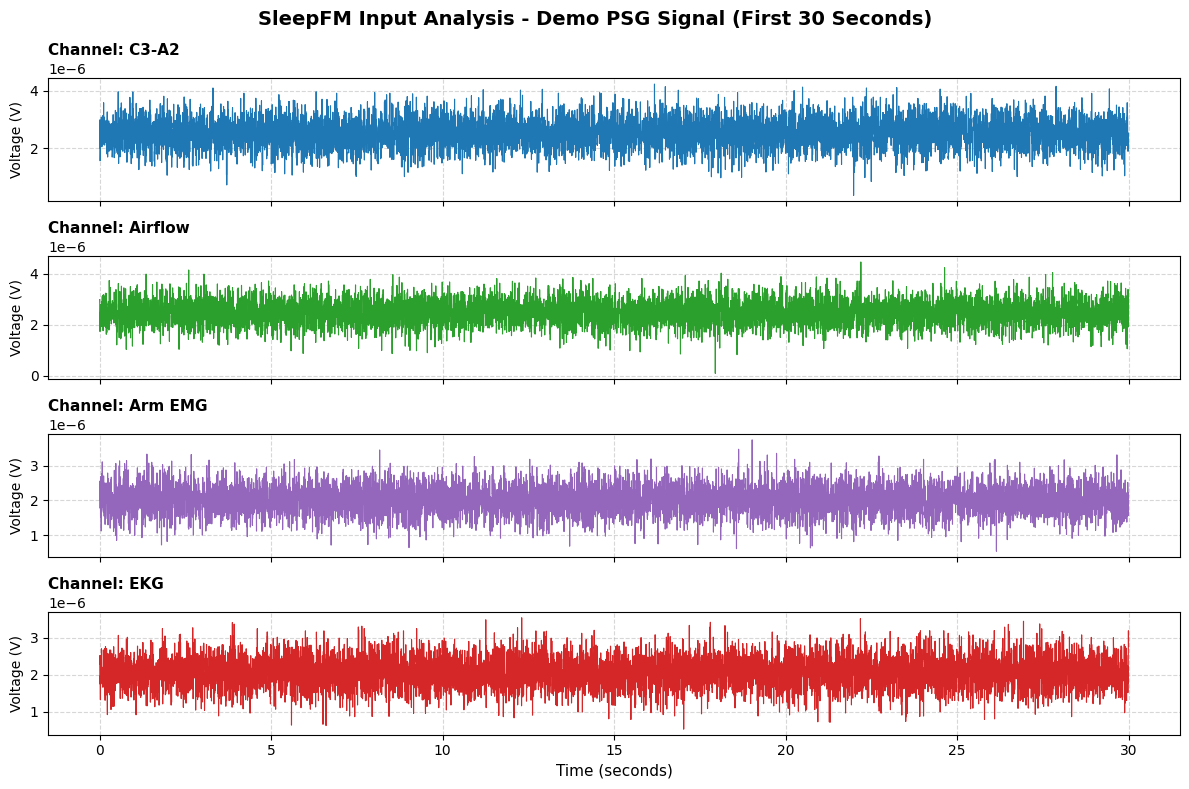

In [7]:
import datetime
import matplotlib.pyplot as plt
from pyedflib import highlevel

# 1. 데이터 불러오기
edf_path = "demo_data/demo_psg.edf"
signals, channel_headers, file_header = highlevel.read_edf(edf_path)

# =================================================================
# [분석 1] 메타데이터 및 전체적인 의미 해석 (텍스트 출력)
# =================================================================
print("=" * 60)
print(f"📊 [EDF 파일 기본 요약 정보]")
print("=" * 60)
print(f"• 기록 시작 시간 : {file_header.get('startdate')}")
print(f"• 환자 ID/이름   : {file_header.get('patientname')}")

print("\n⚙️ [채널별 수면다원검사(PSG) 구성 의미]")
total_samples = len(signals[0])
sample_rate = channel_headers[0]['sample_rate']
total_seconds = total_samples / sample_rate

print(f"• 총 기록 시간   : {total_seconds:.2f}초 (약 {total_seconds/60:.1f}분)")
print(f"• 채널 수         : {len(signals)} 개")

# 채널별 세부 정보 해석
channel_meanings = {
    'C3-A2': '뇌파 (EEG) - 수면 단계(NREM/REM) 및 각성 상태를 판정하는 핵심 채널',
    'Airflow': '호흡 기류 (Respiration) - 수면 중 무호흡증이나 저호흡을 감지하는 채널',
    'Arm EMG': '팔 근전도 (EMG) - 수면 중 팔 움직임이나 주기적 사지운동증(PLMD) 확인 채널',
    'EKG': '심전도 (ECG) - 수면 중 심박수 변화 및 부정맥을 모니터링하는 채널'
}

for i, ch in enumerate(channel_headers):
    label = ch['label']
    meaning = channel_meanings.get(label, "생체 신호 채널")
    print(f"\n[{i+1}] {label} ({meaning})")
    print(f"    - 샘플링 레이트 : {ch['sample_rate']} Hz (1초에 {int(ch['sample_rate'])}번 측정)")
    print(f"    - 단위 및 진폭   : {ch['dimension']} (최대 {ch['physical_max']}V ~ 최소 {ch['physical_min']}V)")
    print(f"    - 데이터 개수   : {len(signals[i])} samples")

# =================================================================
# [분석 2] 생체 신호 데이터 시각화 (첫 30초 구간 확인)
# =================================================================
# 수면 다원 검사의 표준 판독 단위인 '30초(Epoch)'를 기준으로 시각화합니다.
view_seconds = 30  
num_samples_to_plot = int(view_seconds * sample_rate)

# X축 시간 데이터 생성 (0초부터 30초까지)
time_axis = [t / sample_rate for t in range(num_samples_to_plot)]

# 4개 채널을 각각 그리기 위한 그래프 틀 생성
fig, axes = plt.subplots(nrows=len(signals), ncols=1, figsize=(12, 8), sharex=True)
fig.suptitle("SleepFM Input Analysis - Demo PSG Signal (First 30 Seconds)", fontsize=14, fontweight='bold')

# 각 채널의 데이터를 하나씩 그래프로 매핑
colors = ['#1f77b4', '#2ca02c', '#9467bd', '#d62728'] # 뇌파, 호흡, 근전도, 심전도 구분 컬러

for i, ch in enumerate(channel_headers):
    label = ch['label']
    unit = ch['dimension']
    
    # 30초 분량만큼 데이터 슬라이싱
    signal_data = signals[i][:num_samples_to_plot]
    
    # 서브플롯 그리기
    axes[i].plot(time_axis, signal_data, color=colors[i], linewidth=0.8)
    axes[i].set_title(f"Channel: {label}", fontsize=11, loc='left', fontweight='bold')
    axes[i].set_ylabel(f"Voltage ({unit})")
    axes[i].grid(True, linestyle='--', alpha=0.5)

# 최하단 X축 설정
axes[-1].set_xlabel("Time (seconds)", fontsize=11)
plt.tight_layout()
plt.show()


In [8]:
root_dir = "/edf_root"      # 여러 파일을 일괄 변환할 때 사용할 더미(Dummy) 원본 디렉터리 경로를 설정합니다. (단일 파일 변환에서는 사용되지 않음)
target_dir = "/note"    # 여러 파일을 일괄 변환할 때 사용할 더미 Target 디렉터리 경로를 설정합니다. (단일 파일 변환에서는 사용되지 않음)

edf_path = "demo_data/demo_psg.edf" #변환할 원본 EDF(European Data Format) 수면 다원 검사 파일의 경로를 지정합니다.
hdf5_path = os.path.join(base_save_path, "demo_psg.hdf5") #변환 결과를 저장할 HDF5 파일 경로를 만듭니다. 이전 단계의 base_save_path("demo_data")와 파일명을 결합하여 "demo_data/demo_psg.hdf5"라는 경로가 생성됩니다.

converter = EDFToHDF5Converter(
    root_dir=root_dir,
    target_dir=target_dir,
    resample_rate=128
)#앞서 불러온 EDFToHDF5Converter 클래스의 인스턴스(객체)를 생성합니다.

# run for single file conversion
converter.convert(edf_path, hdf5_path) #실제로 단일 EDF 파일(edf_path)을 읽어와 128Hz 리샘플링 및 HDF5 포맷 변환을 수행한 뒤, 지정한 경로(hdf5_path)에 저장합니다.

2026-09-20 22:31:05.265 | INFO     | preprocessing.preprocessing:read_edf:146 - reading edf


Extracting EDF parameters from C:\Users\user\sleep_fm_r\notebooks\demo_data\demo_psg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 2234623  =      0.000 ...  8728.996 secs...


2026-09-20 22:31:06.182 | INFO     | preprocessing.preprocessing:resample_signals:184 - resampling signals


Filtering signal
Filtering signal
Filtering signal
Filtering signal


2026-09-20 22:31:06.663 | INFO     | preprocessing.preprocessing:save_to_hdf5:219 - saving hdf5


#### Part 1: Generating embeddings from SleepFM pretrained model

Here we show generating embedding for 1 demno PSG. To see full script, please check `sleepfm/pipeline/generate_embeddings.py`. 

In [9]:
model_path = "../sleepfm/checkpoints/model_base"#사전 학습된 모델 체크포인트 파일들이 들어 있는 기본 폴더 경로를 지정합니다.
channel_groups_path = "../sleepfm/configs/channel_groups.json"#수면 다원 검사 신호(EEG, ECG, EMG 등)의 채널 묶음 정보가 정의된 JSON 파일 경로를 지정합니다.
config_path = os.path.join(model_path, "config.json")#model_path 경로와 파일명을 안전하게 결합하여 모델 설정 파일 경로인 "../sleepfm/checkpoints/model_base/config.json"을 만듭니다.

config = load_config(config_path)#앞서 만든 경로(config_path)의 설정 파일(JSON 또는 YAML 등)을 읽어와 모델 구조, 하이퍼파라미터 등이 담긴 config 객체/딕셔너리로 저장합니다.
channel_groups = load_data(channel_groups_path)#채널 그룹 설정 파일(channel_groups_path)을 읽어와 각 생체 신호 채널의 매핑 정보를 channel_groups 변수에 저장합니다.

In [10]:
print(config)

{'seed': 42, 'model': 'SetTransformer', 'in_channels': 1, 'batch_size': 128, 'epochs': 1, 'lr': 0.001, 'lr_step_period': 2, 'gamma': 0.1, 'temperature': 0.0, 'momentum': 0.9, 'num_workers': 16, 'embed_dim': 128, 'num_heads': 8, 'num_layers': 6, 'pooling_head': 8, 'dropout': 0.3, 'split_path': 'path_to_/dataset_split.json', 'save_path': 'path_to_/models', 'weight_decay': 0.0, 'mode': 'leave_one_out', 'save_iter': 5000, 'eval_iter': 5000, 'log_interval': 100, 'use_wandb': True, 'BAS_CHANNELS': 10, 'RESP_CHANNELS': 7, 'EKG_CHANNELS': 2, 'EMG_CHANNELS': 4, 'max_files': None, 'val_size': 100, 'sampling_duration': 5, 'sampling_freq': 128, 'patch_size': 640, 'modality_types': ['BAS', 'RESP', 'EKG', 'EMG']}


{'seed': 42, 'model': 'SetTransformer', 'in_channels': 1, 'batch_size': 128, 'epochs': 1, 
'lr': 0.001, 'lr_step_period': 2, 'gamma': 0.1, 'temperature': 0.0, 'momentum': 0.9, 
'num_workers': 16, 'embed_dim': 128, 'num_heads': 8, 'num_layers': 6, 'pooling_head': 8, 
'dropout': 0.3, 'split_path': 'path_to_/dataset_split.json', 'save_path': 'path_to_/models', 'weight_decay': 0.0, 'mode': 'leave_one_out', 'save_iter': 5000, 'eval_iter': 5000, 'log_interval': 100, 'use_wandb': True, 'BAS_CHANNELS': 10, 
'RESP_CHANNELS': 7, 'EKG_CHANNELS': 2, 'EMG_CHANNELS': 4, 'max_files': None, 'val_size': 100, 
'sampling_duration': 5, 'sampling_freq': 128, 'patch_size': 640, 'modality_types': ['BAS', 'RESP', 'EKG', 'EMG']}

In [11]:
modality_types = config["modality_types"]#모델이 입력받는 생체 신호 모달리티(양식)의 종류(예: EEG, ECG, EMG 등) 리스트를 가져옵니다.
in_channels = config["in_channels"]#각 신호 모달리티별 입력 채널의 개수(또는 차원)를 가져옵니다.
patch_size = config["patch_size"]#트랜스포머 입력으로 사용하기 위해 시계열 신호를 잘라내는 패치(Patch)의 크기/길이를 가져옵니다.
embed_dim = config["embed_dim"]#트랜스포머 내부에서 신호 데이터를 표현할 임베딩 차원의 크기(Embedding Dimension)를 가져옵니다.
num_heads = config["num_heads"]#트랜스포머의 Multi-Head Attention 연산에서 사용할 헤드(Head)의 개수를 가져옵니다.
num_layers = config["num_layers"]#트랜스포머 인코더/블록을 위로 몇 층(Layer) 쌓을 것인지 레이어 개수를 가져옵니다.
pooling_head = config["pooling_head"]#시계열/채널 차원의 피처들을 하나로 압축할 때 사용할 풀링(Pooling) 방식 및 풀링 헤드 관련 설정을 가져옵니다.
dropout = 0.0#학습이나 추론 시 신경망 내 노드를 임의로 비활성화하는 드롭아웃(Dropout) 비율을 0.0(0%)으로 지정합니다. (추론/평가 단계이므로 드롭아웃을 적용하지 않음)

modality_types = ['BAS', 'RESP', 'EKG', 'EMG']#모델이 입력받는 생체 신호 모달리티(양식)의 종류(예: EEG, ECG, EMG 등) 리스트를 가져옵니다.
in_channels = 1#각 신호 모달리티별 입력 채널의 개수(또는 차원)를 가져옵니다.
patch_size = 640#트랜스포머 입력으로 사용하기 위해 시계열 신호를 잘라내는 패치(Patch)의 크기/길이를 가져옵니다.
embed_dim = 128#트랜스포머 내부에서 신호 데이터를 표현할 임베딩 차원의 크기(Embedding Dimension)를 가져옵니다.
num_heads = 8#트랜스포머의 Multi-Head Attention 연산에서 사용할 헤드(Head)의 개수를 가져옵니다.
num_layers = 6#트랜스포머 인코더/블록을 위로 몇 층(Layer) 쌓을 것인지 레이어 개수를 가져옵니다.
pooling_head = 8#시계열/채널 차원의 피처들을 하나로 압축할 때 사용할 풀링(Pooling) 방식 및 풀링 헤드 관련 설정을 가져옵니다.

In [12]:
model_class = getattr(sys.modules[__name__], config['model'])#config['model']에 적힌 문자열(예: "SetTransformer")을 바탕으로 현재 스코프에 임포트된 클래스 객체를 동적으로 가져옵니다.
#SetTransformer
model = model_class(in_channels, patch_size, embed_dim, num_heads, num_layers, pooling_head=pooling_head, dropout=dropout)
#가져온 모델 클래스(model_class)에 앞서 설정한 하이퍼파라미터들을 전달하여 실제로 인스턴스화(생성)합니다.
# Use GPU if available, otherwise default to CPU safely

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#GPU(CUDA)를 사용할 수 있으면 "cuda", 그렇지 않으면 "cpu"를 선택하여 연산 장치(device)로 지정합니다.
model = model.to(device)
#생성한 모델을 지정한 연산 장치(GPU 또는 CPU)의 메모리로 이동시킵니다.

if device.type == "cuda" and torch.cuda.device_count() > 1:#현재 장치가 GPU이고, 사용 가능한 GPU 개수가 2개 이상인지 확인하는 조건문입니다.
    model = torch.nn.DataParallel(model)
#여러 개의 GPU가 있을 경우, 데이터를 병렬로 나누어 연산할 수 있도록 모델을 DataParallel로 감쌉니다.

model.to(device)
#DataParallel 적용 후 모델을 다시 해당 연산 장치에 확실하게 할당합니다.

total_layers, total_params = count_parameters(model)
#앞서 가져온 유틸리티 함수 count_parameters를 이용해 모델의 전체 레이어 수와 파라미터 수를 계산합니다.

print(f'Trainable parameters: {total_params / 1e6:.2f} million')
#학습 가능한 파라미터 수(total_params)를 백만(1e6) 단위로 나누어 소수점 둘째 자리까지 출력합니다.
print(f'Number of layers: {total_layers}')
#모델의 총 레이어 개수를 출력합니다.

Trainable parameters: 4.44 million
Number of layers: 93


C:\Users\user\anaconda3\envs\sleepfm_env\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [13]:
checkpoint = torch.load(os.path.join(model_path, "best.pt"), weights_only=False)
state_dict = checkpoint["state_dict"]

# module. 접두사 제거
new_state_dict = {}
for k, v in state_dict.items():
    name = k.replace("module.", "") if k.startswith("module.") else k
    new_state_dict[name] = v

# 모델에 가중치 로드
model.load_state_dict(new_state_dict)
model.eval()

SetTransformer(
  (patch_embedding): Tokenizer(
    (tokenizer): Sequential(
      (0): Conv1d(1, 4, kernel_size=(5,), stride=(2,), padding=(2,))
      (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ELU(alpha=1.0)
      (3): LayerNorm((4, 320), eps=1e-05, elementwise_affine=True)
      (4): Conv1d(4, 8, kernel_size=(5,), stride=(2,), padding=(2,))
      (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ELU(alpha=1.0)
      (7): LayerNorm((8, 160), eps=1e-05, elementwise_affine=True)
      (8): Conv1d(8, 16, kernel_size=(5,), stride=(2,), padding=(2,))
      (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ELU(alpha=1.0)
      (11): LayerNorm((16, 80), eps=1e-05, elementwise_affine=True)
      (12): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
      (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [14]:
config

{'seed': 42,
 'model': 'SetTransformer',
 'in_channels': 1,
 'batch_size': 128,
 'epochs': 1,
 'lr': 0.001,
 'lr_step_period': 2,
 'gamma': 0.1,
 'temperature': 0.0,
 'momentum': 0.9,
 'num_workers': 16,
 'embed_dim': 128,
 'num_heads': 8,
 'num_layers': 6,
 'pooling_head': 8,
 'dropout': 0.3,
 'split_path': 'path_to_/dataset_split.json',
 'save_path': 'path_to_/models',
 'weight_decay': 0.0,
 'mode': 'leave_one_out',
 'save_iter': 5000,
 'eval_iter': 5000,
 'log_interval': 100,
 'use_wandb': True,
 'BAS_CHANNELS': 10,
 'RESP_CHANNELS': 7,
 'EKG_CHANNELS': 2,
 'EMG_CHANNELS': 4,
 'max_files': None,
 'val_size': 100,
 'sampling_duration': 5,
 'sampling_freq': 128,
 'patch_size': 640,
 'modality_types': ['BAS', 'RESP', 'EKG', 'EMG']}

In [15]:
hdf5_paths = [os.path.join(base_save_path, "demo_psg.hdf5")]#변환결과 불러오기
dataset = SetTransformerDataset(config, channel_groups, hdf5_paths=hdf5_paths, split="test")

dataloader = torch.utils.data.DataLoader(dataset, 
                                            batch_size=16, 
                                            num_workers=1, 
                                            shuffle=False, 
                                            collate_fn=collate_fn)

Indexing files: 100%|████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.32s/it]


In [17]:
output = os.path.join(base_save_path, "demo_emb")
output_5min_agg = os.path.join(base_save_path, "demo_5min_agg_emb")
os.makedirs(output, exist_ok=True)
os.makedirs(output_5min_agg, exist_ok=True)

In [18]:
with torch.no_grad():
    with tqdm.tqdm(total=len(dataloader)) as pbar:
        for batch in dataloader:
            batch_data, mask_list, file_paths, dset_names_list, chunk_starts = batch
            (bas, resp, ekg, emg) = batch_data
            (mask_bas, mask_resp, mask_ekg, mask_emg) = mask_list

            bas = bas.to(device, dtype=torch.float)
            resp = resp.to(device, dtype=torch.float)
            ekg = ekg.to(device, dtype=torch.float)
            emg = emg.to(device, dtype=torch.float)

            mask_bas = mask_bas.to(device, dtype=torch.bool)
            mask_resp = mask_resp.to(device, dtype=torch.bool)
            mask_ekg = mask_ekg.to(device, dtype=torch.bool)
            mask_emg = mask_emg.to(device, dtype=torch.bool)

            embeddings = [
                model(bas, mask_bas),
                model(resp, mask_resp),
                model(ekg, mask_ekg),
                model(emg, mask_emg),
            ]

            # Model gives two kinds of embeddings. Granular 5 second-level embeddings and aggregated 5 minute-level embeddings. We save both of them below. 

            embeddings_new = [e[0].unsqueeze(1) for e in embeddings]

            for i in range(len(file_paths)):
                file_path = file_paths[i]
                chunk_start = chunk_starts[i]
                subject_id = os.path.basename(file_path).split('.')[0]
                output_path = os.path.join(output_5min_agg, f"{subject_id}.hdf5")

                with h5py.File(output_path, 'a') as hdf5_file:
                    for modality_idx, modality_type in enumerate(config["modality_types"]):
                        if modality_type in hdf5_file:
                            dset = hdf5_file[modality_type]
                            chunk_start_correct = chunk_start // (embed_dim * 5 * 60)
                            chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                            if dset.shape[0] < chunk_end:
                                dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                            dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                        else:
                            hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])

            embeddings_new = [e[1] for e in embeddings]

            for i in range(len(file_paths)):
                file_path = file_paths[i]
                chunk_start = chunk_starts[i]
                subject_id = os.path.basename(file_path).split('.')[0]
                output_path = os.path.join(output, f"{subject_id}.hdf5")

                with h5py.File(output_path, 'a') as hdf5_file:
                    for modality_idx, modality_type in enumerate(config["modality_types"]):
                        if modality_type in hdf5_file:
                            dset = hdf5_file[modality_type]
                            chunk_start_correct = chunk_start // (embed_dim * 5)
                            chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                            if dset.shape[0] < chunk_end:
                                dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                            dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                        else:
                            hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])
            pbar.update()

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:05<00:00,  2.88s/it]


#### Part 2: Sleep Staging

Note that below, we are using our finetuned sleep staging model. It is always a good idea to finetune our model on your specific data, even if you only have a handful of sample, so that the model can adapt to your specific data distribution. Script to finetune your sleep staging model head is given in `sleepfm/pipeline/finetune_sleep_staging.py`. 

In [19]:
sleep_staging_model_path = "../sleepfm/checkpoints/model_sleep_staging"
sleep_staging_config = load_data(os.path.join(sleep_staging_model_path, "config.json"))

sleep_staging_model_params = sleep_staging_config['model_params']
sleep_staging_model_class = getattr(sys.modules[__name__], sleep_staging_config['model'])

sleep_staging_model = sleep_staging_model_class(**sleep_staging_model_params).to(device)
sleep_staging_model_name = type(sleep_staging_model).__name__

C:\Users\user\anaconda3\envs\sleepfm_env\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [20]:
sleep_staging_model = nn.DataParallel(sleep_staging_model)
print(f"Using {torch.cuda.device_count()} GPUs")

Using 1 GPUs


In [21]:
print(f"Model initialized: {sleep_staging_model_name}")
total_layers, total_params = count_parameters(sleep_staging_model)
print(f'Trainable parameters: {total_params / 1e6:.2f} million')
print(f'Number of layers: {total_layers}')

Model initialized: SleepEventLSTMClassifier
Trainable parameters: 1.19 million
Number of layers: 20


In [22]:
sleep_staging_checkpoint_path = os.path.join(sleep_staging_model_path, "best.pth")
sleep_staging_checkpoint = torch.load(
    sleep_staging_checkpoint_path, 
    weights_only=True
)
sleep_staging_model.load_state_dict(sleep_staging_checkpoint)

<All keys matched successfully>

Below are some helper functions for loading data for sleep staging. You can find similar functions within `sleepfm/models/dataset.py`. You may need to modify it slightly based on your usecase. 

In [23]:
class SleepEventClassificationDataset(Dataset):
    def __init__(
        self,
        config,
        channel_groups,
        hdf5_paths,
        label_files,
        split="train",
    ):
        self.config = config
        self.max_channels = self.config["max_channels"]
        self.context = int(self.config["context"])
        self.channel_like = self.config["channel_like"]

        self.max_seq_len = config["model_params"]["max_seq_length"]

        # --- Build label lookup: {study_id: label_csv_path} ---
        # study_id = filename without extension, e.g. "SSC_12345"
        labels_dict = {
            os.path.basename(p).rsplit(".", 1)[0]: p
            for p in label_files
            if os.path.exists(p)
        }

        # --- Filter to HDF5s that exist and have a matching label file ---
        hdf5_paths = [p for p in hdf5_paths if os.path.exists(p)]
        hdf5_paths = [
            p for p in hdf5_paths
            if os.path.basename(p).rsplit(".", 1)[0] in labels_dict
        ]

        if config.get("max_files"):
            hdf5_paths = hdf5_paths[: config["max_files"]]

        self.hdf5_paths = hdf5_paths
        self.labels_dict = labels_dict

        # --- Build index map ---
        # Each item is (hdf5_path, label_path, start_index)
        if self.context == -1:
            self.index_map = [
                (p, labels_dict[os.path.basename(p).rsplit(".", 1)[0]], -1)
                for p in self.hdf5_paths
            ]
        else:
            self.index_map = []
            loop = tqdm(self.hdf5_paths, total=len(self.hdf5_paths), desc=f"Indexing {split} data")
            for hdf5_file_path in loop:
                file_prefix = os.path.basename(hdf5_file_path).rsplit(".", 1)[0]
                label_path = labels_dict[file_prefix]

                with h5py.File(hdf5_file_path, "r") as hf:
                    dset_names = list(hf.keys())
                    if len(dset_names) == 0:
                        continue

                    # Use first dataset to define length (same as your original behavior)
                    first_name = dset_names[0]
                    dataset_length = hf[first_name].shape[0]

                for i in range(0, dataset_length, self.context):
                    self.index_map.append((hdf5_file_path, label_path, i))

        # If you have logger, keep; otherwise you can remove these.
        # logger.info(f"Number of files in {split} set: {len(self.hdf5_paths)}")
        # logger.info(f"Number of files to be processed in {split} set: {len(self.index_map)}")

        self.total_len = len(self.index_map)

    def __len__(self):
        return self.total_len

    def get_index_map(self):
        return self.index_map

    def __getitem__(self, idx):
        hdf5_path, label_path, start_index = self.index_map[idx]

        labels_df = pd.read_csv(label_path)
        labels_df["StageNumber"] = labels_df["StageNumber"].replace(-1, 0)

        y_data = labels_df["StageNumber"].to_numpy()
        if self.context != -1:
            y_data = y_data[start_index : start_index + self.context]

        x_data = []
        with h5py.File(hdf5_path, "r") as hf:
            dset_names = list(hf.keys())

            for dataset_name in dset_names:
                if dataset_name in self.channel_like:
                    if self.context == -1:
                        x_data.append(hf[dataset_name][:])
                    else:
                        x_data.append(hf[dataset_name][start_index : start_index + self.context])

        if not x_data:
            # Skip this data point if x_data is empty
            return self.__getitem__((idx + 1) % self.total_len)

        x_data = np.array(x_data)  # (C, T, F) assuming each channel returns (T, F)
        x_data = torch.tensor(x_data, dtype=torch.float32)
        y_data = torch.tensor(y_data, dtype=torch.float32)

        min_length = min(x_data.shape[1], len(y_data))
        x_data = x_data[:, :min_length, :]
        y_data = y_data[:min_length]

        return x_data, y_data, self.max_channels, self.max_seq_len, hdf5_path


def sleep_event_finetune_full_collate_fn(batch):
    x_data, y_data, max_channels_list, max_seq_len_list, hdf5_path_list = zip(*batch)

    num_channels = max(max_channels_list)

    max_seq_len_temp = max([item.size(1) for item in x_data])
    # Determine the max sequence length for padding
    if max_seq_len_list[0] is None:
        max_seq_len = max_seq_len_temp
    else:
        max_seq_len = min(max_seq_len_temp, max_seq_len_list[0])

    padded_x_data = []
    padded_y_data = []
    padded_mask = []

    for x_item, y_item in zip(x_data, y_data):

        # first non-zero index of y_data
        #print(y_item.shape)


        tgt_sleep_no_sleep = np.where(y_item > 0, 1, 0)
        moving_avg_tgt_sleep_no_sleep = np.convolve(tgt_sleep_no_sleep, np.ones(1080)/1080, mode='valid')
        try:
            first_non_zero_index = np.where(moving_avg_tgt_sleep_no_sleep > 0.5)[0][0]
        except IndexError:
            first_non_zero_index = 0



        #non_zero_indices = (y_item != 0).nonzero(as_tuple=True)[0]
        #first_non_zero_index = non_zero_indices[0].item() - 20
        if first_non_zero_index < 0:
            first_non_zero_index = 0

        #first_non_zero_index = 0

        #print(f"First non-zero index of y_data: {first_non_zero_index}")
        # Get the shape of x_item
        c, s, e = x_item.size()
        c = min(c, num_channels)
        s = min(s, max_seq_len + first_non_zero_index)  # Ensure the sequence length doesn't exceed max_seq_len

        # Create a padded tensor and a mask tensor for x_data
        padded_x_item = torch.zeros((num_channels, max_seq_len, e))
        mask = torch.ones((num_channels, max_seq_len))

        # Copy the actual data to the padded tensor and set the mask for real data
        #print(f"Shape of x_item: {x_item[:c, first_non_zero_index:s, :e].shape}")
        padded_x_item[:c, :s-first_non_zero_index, :e] = x_item[:c, first_non_zero_index:s, :e]
        mask[:c, :s-first_non_zero_index] = 0  # 0 for real data, 1 for padding

        # Pad y_data with zeros to match max_seq_len
        padded_y_item = torch.zeros(max_seq_len)
        padded_y_item[:s-first_non_zero_index] = y_item[first_non_zero_index:s]

        # Append padded items to lists
        padded_x_data.append(padded_x_item)
        padded_y_data.append(padded_y_item)
        padded_mask.append(mask)

    # Stack all tensors into a batch
    x_data = torch.stack(padded_x_data)
    y_data = torch.stack(padded_y_data)
    padded_mask = torch.stack(padded_mask)

    '''
    for y_data_mini in y_data:
        unique_labels = torch.unique(y_data_mini)
        print(f"Unique labels in batch: {unique_labels}")
    '''

    return x_data, y_data, padded_mask, hdf5_path_list

In [24]:
hdf5_paths = [os.path.join(base_save_path, "demo_emb/demo_psg.hdf5")]
label_files = [os.path.join(base_save_path, "demo_psg.csv")]
test_dataset = SleepEventClassificationDataset(sleep_staging_config, channel_groups, split="test", hdf5_paths=hdf5_paths, label_files=label_files)

In [25]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0, collate_fn=sleep_event_finetune_full_collate_fn)

In [26]:
# Validation loop at the end of each epoch
model.eval()
all_targets = []
all_logits = []
all_outputs = []
all_masks = []
all_paths = []

count = 0
with torch.no_grad():
    for (x_data, y_data, padded_matrix, hdf5_path_list) in tqdm.tqdm(test_loader, desc="Evaluating"):
        x_data, y_data, padded_matrix, hdf5_path_list = x_data.to(device), y_data.to(device), padded_matrix.to(device), list(hdf5_path_list)
        outputs, mask = sleep_staging_model(x_data, padded_matrix)
        all_targets.append(y_data.cpu().numpy())
        all_outputs.append(torch.softmax(outputs, dim=-1).cpu().numpy())
        all_logits.append(outputs.cpu().numpy())
        all_masks.append(mask.cpu().numpy())
        all_paths.append(hdf5_path_list)


save_path = os.path.join(base_save_path, "demo_sleep_staging")
os.makedirs(save_path, exist_ok=True)

targets_path = os.path.join(save_path, "all_targets.pickle")
outputs_path = os.path.join(save_path, "all_outputs.pickle")
logits_path = os.path.join(save_path, "all_logits.pickle")
mask_path = os.path.join(save_path, "all_masks.pickle")
file_paths = os.path.join(save_path, "all_paths.pickle")

save_data(all_targets, targets_path)
save_data(all_outputs, outputs_path)
save_data(all_logits, logits_path)
save_data(all_masks, mask_path)
save_data(all_paths, file_paths)

Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.38it/s]


In [27]:
all_outputs[0].shape, all_targets[0].shape

((1, 1740, 5), (1, 1740))

In [28]:
len(all_logits), len(all_outputs), len(all_targets), len(all_masks)

(1, 1, 1, 1)

In [29]:
all_logits[0].shape, all_outputs[0].shape, all_targets[0].shape, all_masks[0].shape

((1, 1740, 5), (1, 1740, 5), (1, 1740), (1, 1740))

In [30]:
all_logits_flat = [logits.reshape(-1, logits.shape[-1]) for logits in all_logits]
all_outputs_flat = [outputs.reshape(-1, outputs.shape[-1]) for outputs in all_outputs]
all_targets_flat = [targets.reshape(-1) for targets in all_targets]
all_masks_flat = [mask.reshape(-1) for mask in all_masks]

# Convert lists of flattened arrays to single concatenated arrays if desired
all_logits_flat = np.concatenate(all_logits_flat, axis=0)
all_outputs_flat = np.concatenate(all_outputs_flat, axis=0)
all_targets_flat = np.concatenate(all_targets_flat, axis=0)
all_masks_flat = np.concatenate(all_masks_flat, axis=0)

In [31]:
all_logits_flat.shape, all_outputs_flat.shape, all_targets_flat.shape, all_masks_flat.shape

((1740, 5), (1740, 5), (1740,), (1740,))

In [32]:
mask_filter = all_masks_flat == 0

# Apply the mask to each flattened array
all_logits_filtered = all_logits_flat[mask_filter]
all_outputs_filtered = all_outputs_flat[mask_filter]
all_targets_filtered = all_targets_flat[mask_filter]

In [33]:
counts = Counter(all_targets_filtered)
total = sum(counts.values())
prevalence_dict = {cls: count / total for cls, count in counts.items()}
prevalence_dict

{0.0: 0.367816091954023,
 1.0: 0.1511494252873563,
 4.0: 0.16839080459770114,
 3.0: 0.15402298850574714,
 2.0: 0.15862068965517243}

In [34]:
class_labels = ["Wake", "Stage 1", "Stage 2", "Stage 3", "REM"]
# class_labels = ["No-Apnea", "Apnea"]
class_mapping = {label: idx for idx, label in enumerate(class_labels)}

F1 Score for Wake: 0.538
F1 Score for Stage 1: 0.000
F1 Score for Stage 2: 0.000
F1 Score for Stage 3: 0.000
F1 Score for REM: 0.000


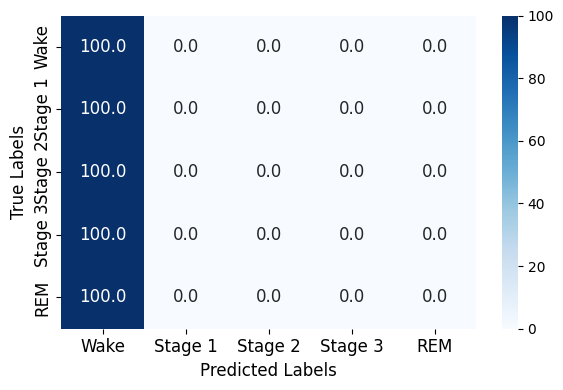

In [35]:
# Step 1: Get predicted labels (argmax on probabilities)
predicted_labels = np.argmax(all_outputs_filtered, axis=1)

fontsize = 12

# Step 2: Compute F1 score for each class
f1_scores = f1_score(all_targets_filtered, predicted_labels, average=None, labels=range(len(class_labels)))
for idx, label in enumerate(class_labels):
    print(f"F1 Score for {label}: {f1_scores[idx]:.3f}")

# Step 3: Create a confusion matrix and normalize it by row to get percentages
conf_matrix = confusion_matrix(all_targets_filtered, predicted_labels, labels=range(len(class_labels)))
conf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1, keepdims=True) * 100

# Plotting the confusion matrix with percentages
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={"size": fontsize},  # Font size for numbers inside the heatmap
    cbar_kws={"shrink": 1},  # Adjust colorbar size
)

# Customizing axis labels and ticks
plt.xlabel("Predicted Labels", fontsize=fontsize)
plt.ylabel("True Labels", fontsize=fontsize)
plt.xticks(fontsize=12, ha="center")  # Font size for x-axis tick labels with rotation
plt.yticks(fontsize=12)  # Font size for y-axis tick labels

# Adjust layout and save the figure
plt.tight_layout()
plt.show()

In [36]:
#결과 추가
import numpy as np
import torch  # PyTorch 사용 기준 (TensorFlow 사용 시 np.array 변환 적용)

print("=" * 50)
print("1. 클래스별 데이터 개수 및 비율 확인 (Class Imbalance Check)")
print("=" * 50)
# 진단 코드 가장 맨 위에 이 줄을 추가해주시면 안전합니다.
all_targets_filtered = np.array(all_targets_filtered, dtype=int)
# 실제 정답 라벨의 클래스별 개수 집계
unique_classes, counts = np.unique(all_targets_filtered, return_counts=True)
total_samples = len(all_targets_filtered)

# 수정된 루프 코드 (int(cls) 적용)
for cls, count in zip(unique_classes, counts):
    cls_int = int(cls)  # numpy.float32를 int로 변환
    label_name = (
        class_labels[cls_int]
        if cls_int < len(class_labels)
        else f"Class {cls_int}"
    )
    percentage = (count / total_samples) * 100
    print(
        f"Label [{cls_int}] ({label_name}): {count:6d}개 ({percentage:5.2f}%)"
    )
print("\n" + "=" * 50)
print("2. 모델 출력값(Output Shape & Probability) 상태 확인")
print("=" * 50)

# 출력 데이터의 Shape 확인
print(f"all_outputs_filtered Shape: {all_outputs_filtered.shape}")
print(f"all_targets_filtered Shape: {all_targets_filtered.shape}")

# 상위 5개 샘플에 대한 소프트맥스 확률값 및 예측 결과 출력
# (만약 logits 상태라면 Softmax 적용)
if np.max(all_outputs_filtered) > 1.0 or np.min(all_outputs_filtered) < 0.0:
    # PyTorch 기준 Softmax 계산 예시
    probs = (
        torch.softmax(torch.tensor(all_outputs_filtered), dim=1).numpy()
        if isinstance(all_outputs_filtered, (np.ndarray, list))
        else all_outputs_filtered
    )
else:
    probs = all_outputs_filtered

print("\n[상위 5개 샘플의 클래스별 예측 확률(%)]")
for i in range(min(5, len(probs))):
    prob_percent = probs[i] * 100
    pred_cls = np.argmax(prob_percent)
    true_cls = all_targets_filtered[i]
    print(f"Sample {i+1}:")
    print(
        f"  - 실제 정답: {class_labels[true_cls]} (Class {true_cls})"
    )
    print(
        f"  - 모델 예측: {class_labels[pred_cls]} (Class {pred_cls})"
    )
    print(
        f"  - 각 클래스 확률: {np.array2string(prob_percent, precision=1, suppress_small=True)}"
    )

print("\n" + "=" * 50)
print("3. 전체 샘플에 대한 클래스별 평균 예측 확률")
print("=" * 50)

# 전체 데이터 세트에 대해 모델이 각 클래스일 확률을 평균 몇 %로 내고 있는지 확인
mean_probs = np.mean(probs, axis=0) * 100
for idx, label in enumerate(class_labels):
    print(f"Average Probability for {label:7s}: {mean_probs[idx]:5.2f}%")

1. 클래스별 데이터 개수 및 비율 확인 (Class Imbalance Check)
Label [0] (Wake):    640개 (36.78%)
Label [1] (Stage 1):    263개 (15.11%)
Label [2] (Stage 2):    276개 (15.86%)
Label [3] (Stage 3):    268개 (15.40%)
Label [4] (REM):    293개 (16.84%)

2. 모델 출력값(Output Shape & Probability) 상태 확인
all_outputs_filtered Shape: (1740, 5)
all_targets_filtered Shape: (1740,)

[상위 5개 샘플의 클래스별 예측 확률(%)]
Sample 1:
  - 실제 정답: Wake (Class 0)
  - 모델 예측: Wake (Class 0)
  - 각 클래스 확률: [97.   0.4  1.4  0.4  0.8]
Sample 2:
  - 실제 정답: Wake (Class 0)
  - 모델 예측: Wake (Class 0)
  - 각 클래스 확률: [97.5  0.6  1.3  0.2  0.4]
Sample 3:
  - 실제 정답: Wake (Class 0)
  - 모델 예측: Wake (Class 0)
  - 각 클래스 확률: [96.1  1.   1.9  0.2  0.9]
Sample 4:
  - 실제 정답: Wake (Class 0)
  - 모델 예측: Wake (Class 0)
  - 각 클래스 확률: [98.4  0.5  0.8  0.1  0.2]
Sample 5:
  - 실제 정답: Wake (Class 0)
  - 모델 예측: Wake (Class 0)
  - 각 클래스 확률: [98.3  0.4  0.9  0.1  0.3]

3. 전체 샘플에 대한 클래스별 평균 예측 확률
Average Probability for Wake   : 89.03%
Average Probability for Stage 1:  1.79%
A

#### Part 3: Disease Prediction

In [37]:
disease_model_path = "../sleepfm/checkpoints/model_diagnosis"
config = load_data(os.path.join(disease_model_path, "config.json"))

In [38]:
config["model_params"]["dropout"] = 0.0
model_params = config['model_params']
model_class = getattr(sys.modules[__name__], config['model'])
model = model_class(**model_params).to(device)
model_name = type(model).__name__

In [39]:
model = nn.DataParallel(model)
print(f"Model initialized: {model_name}")
total_layers, total_params = count_parameters(model)
print(f'Trainable parameters: {total_params / 1e6:.2f} million')
print(f'Number of layers: {total_layers}')

Model initialized: DiagnosisFinetuneFullLSTMCOXPHWithDemo
Trainable parameters: 0.91 million
Number of layers: 15


In [40]:
checkpoint_path = os.path.join(disease_model_path, "best.pth")

In [41]:
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint)

C:\Users\user\AppData\Local\Temp\ipykernel_3060\2254764488.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


<All keys matched successfully>

In [42]:
class DiagnosisFinetuneFullCOXPHWithDemoDataset(Dataset):
    def __init__(self, 
                 config,
                 channel_groups,
                 hdf5_paths=None,
                 demo_labels_path=None,
                 split="train"):

        self.config = config
        self.channel_groups = channel_groups
        self.max_channels = self.config["max_channels"]

        # --- Load demographic features ---
        if not demo_labels_path:
            demo_labels_path = config["demo_labels_path"]

        demo_labels_df = pd.read_csv(demo_labels_path)
        demo_labels_df = demo_labels_df.set_index("Study ID")
        study_ids = set(demo_labels_df.index)

        is_event_df = pd.read_csv(os.path.join(self.config["labels_path"], "is_event.csv"))
        event_time_df = pd.read_csv(os.path.join(self.config["labels_path"], "time_to_event.csv"))

        is_event_df = is_event_df.set_index('Study ID')
        event_time_df = event_time_df.set_index('Study ID')

        # --- Resolve HDF5 paths (explicit precedence) ---
        if hdf5_paths:
            # Use provided paths directly
            hdf5_paths = [f for f in hdf5_paths if os.path.exists(f)]
        else:
            # Load from split file
            split_paths = load_data(config["split_path"])[split]
            hdf5_paths = [f for f in split_paths if os.path.exists(f)]

        # Filter by available demo labels
        hdf5_paths = [
            f for f in hdf5_paths
            if os.path.basename(f).split(".")[0] in study_ids
        ]

        # Optional truncation
        if config.get("max_files"):
            hdf5_paths = hdf5_paths[:config["max_files"]]

        labels_dict = {}
        # Loop over each study_id
        for study_id in tqdm.tqdm(study_ids):
            # Extract the row as a whole for both dataframes (faster than iterating over columns)
            is_event_row = list(is_event_df.loc[study_id].values)
            event_time_row = list(event_time_df.loc[study_id].values)
            demo_feats = list(demo_labels_df.loc[study_id].values)

            # values = [[event_time, is_event] for is_event, event_time in zip(is_event_row, event_time_row)]
            labels_dict[study_id] = {
                "is_event": is_event_row,
                "event_time": event_time_row, 
                "demo_feats": demo_feats
            }

        # --- Build index map ---
        self.index_map = [
            (path, labels_dict[os.path.basename(path).split(".")[0]])
            for path in hdf5_paths
        ]

        print(f"Number of files in {split} set: {len(hdf5_paths)}")
        print(f"Number of files to be processed in {split} set: {len(self.index_map)}")

        self.total_len = len(self.index_map)
        self.max_seq_len = config["model_params"]["max_seq_length"]

        if self.total_len == 0:
            raise ValueError(f"No valid HDF5 files found for split='{split}'.")

    def __len__(self):
        return self.total_len

    def __getitem__(self, idx):
        hdf5_path, tte_event = self.index_map[idx]

        event_time = tte_event["event_time"]
        is_event = tte_event["is_event"]
        demo_feats = tte_event["demo_feats"]

        x_data = []
        with h5py.File(hdf5_path, 'r') as hf:
            dset_names = []
            for dset_name in hf.keys():
                if isinstance(hf[dset_name], h5py.Dataset) and dset_name in self.config["modality_types"]:
                    dset_names.append(dset_name)
            
            random.shuffle(dset_names)
            for dataset_name in dset_names:
                x_data.append(hf[dataset_name][:])

        if not x_data:
            # Skip this data point if x_data is empty
            return self.__getitem__((idx + 1) % self.total_len)

        # Convert x_data list to a single numpy array
        x_data = np.array(x_data)

        # Convert x_data to tensor
        x_data = torch.tensor(x_data, dtype=torch.float32)

        event_time = torch.tensor(event_time, dtype=torch.float32)
        is_event = torch.tensor(is_event) 

        demo_feats = torch.tensor(demo_feats, dtype=torch.float32)

        return x_data, event_time, is_event, demo_feats, self.max_channels, self.max_seq_len, hdf5_path


def diagnosis_finetune_full_coxph_with_demo_collate_fn(batch):
    x_data, event_time, is_event, demo_feats, max_channels_list, max_seq_len_list, hdf5_path_list = zip(*batch)

    num_channels = max(max_channels_list)

    if max_seq_len_list[0] == None:
        max_seq_len = max([item.size(1) for item in x_data])
    else:
        max_seq_len = max_seq_len_list[0]

    padded_x_data = []
    padded_mask = []
    for item in x_data:
        c, s, e = item.size()
        c = min(c, num_channels)
        s = min(s, max_seq_len)  # Ensure the sequence length doesn't exceed max_seq_len

        # Create a padded tensor and a mask tensor
        padded_item = torch.zeros((num_channels, max_seq_len, e))
        mask = torch.ones((num_channels, max_seq_len))

        # Copy the actual data to the padded tensor and set the mask for real data
        padded_item[:c, :s, :e] = item[:c, :s, :e]
        mask[:c, :s] = 0  # 0 for real data, 1 for padding

        padded_x_data.append(padded_item)
        padded_mask.append(mask)
    
    # Stack all tensors into a batch
    x_data = torch.stack(padded_x_data)
    event_time = torch.stack(event_time)
    is_event = torch.stack(is_event)
    demo_feats = torch.stack(demo_feats)
    padded_mask = torch.stack(padded_mask)
    
    return x_data, event_time, is_event, demo_feats, padded_mask, hdf5_path_list

In [43]:
save_path = os.path.join(base_save_path, "demo_diagnosis")
os.makedirs(save_path, exist_ok=True)

In [44]:
hdf5_paths = [os.path.join(base_save_path, "demo_emb/demo_psg.hdf5")]
demo_labels_path = os.path.join(base_save_path, "demo_age_gender.csv")
config["labels_path"] = base_save_path

test_dataset = DiagnosisFinetuneFullCOXPHWithDemoDataset(config, channel_groups, split="test", hdf5_paths=hdf5_paths, demo_labels_path=demo_labels_path)

100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 995.80it/s]

Number of files in test set: 1
Number of files to be processed in test set: 1


In [45]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0, collate_fn=diagnosis_finetune_full_coxph_with_demo_collate_fn)

In [46]:
model.eval()
all_event_times = []
all_is_event = []
all_outputs = []
all_paths = []

with torch.no_grad():
    for item in tqdm.tqdm(test_loader, desc="Evaluating"):
        x_data, event_times, is_event, demo_feats, padded_matrix, hdf5_path_list = item
        x_data, event_times, is_event, demo_feats, padded_matrix, hdf5_path_list = x_data.to(device), event_times.to(device), is_event.to(device), demo_feats.to(device), padded_matrix.to(device), list(hdf5_path_list)
        outputs = model(x_data, padded_matrix, demo_feats)
    
        logits = outputs.cpu().numpy()
        all_outputs.append(logits)
        all_event_times.append(event_times.cpu().numpy())
        all_is_event.append(is_event.cpu().numpy())
        all_paths.append(hdf5_path_list)

all_outputs = np.concatenate(all_outputs, axis=0)
all_event_times = np.concatenate(all_event_times, axis=0)
all_is_event = np.concatenate(all_is_event, axis=0)
all_paths = np.concatenate(all_paths)

outputs_path = os.path.join(save_path, "all_outputs.pickle")
event_times_path = os.path.join(save_path, "all_event_times.pickle")
is_event_path = os.path.join(save_path, "all_is_event.pickle")
file_paths = os.path.join(save_path, "all_paths.pickle")

save_data(all_outputs, outputs_path)
save_data(all_event_times, event_times_path)
save_data(all_is_event, is_event_path)
save_data(all_paths, file_paths)

Evaluating: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.78it/s]


In [47]:
all_outputs.shape, all_event_times.shape, all_is_event.shape

((1, 1065), (1, 1065), (1, 1065))

Above, you get the model outputs, which you can then use to look for specific disease diagnosis. Nope that the shape of the output above is 1065, meaning, this model gives logprobs for 1065 conditions. We provide information about each disease index and its corresponding phecode here `sleepfm/configs/label_mapping.csv`. You can map it as follows. 

In [48]:
labels_df = pd.read_csv("../sleepfm/configs/label_mapping.csv")

In [49]:
labels_df["output"] = all_outputs[0]
labels_df["is_event"] = all_is_event[0]
labels_df["event_time"] = all_event_times[0]

In [50]:
labels_df.head()

,label_idx,phecode,phenotype,output,is_event,event_time
0,0,8.0,Intestinal infection,2.382425,0,3845.0
1,1,8.5,Bacterial enteritis,2.941730,0,3845.0
2,2,8.6,Viral Enteritis,3.220654,0,3845.0
3,3,38.0,Septicemia,5.640564,0,3845.0
4,4,38.3,Bacteremia,5.597531,0,3845.0


Above, you get the output hazards from our model, and also your labels for is_event and event_times. Is_event is an indicator for if the event occured and event_time is the time to event